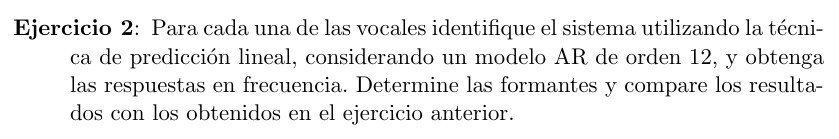

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from scipy.fft import fft, fftfreq, ifft, fftshift

In [143]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

salida = cargar_dataset("PDS_Datos_TP2/aeiou_mas.txt")
N = len(salida)
print(salida.shape)

frecM = 8000

(36000,)


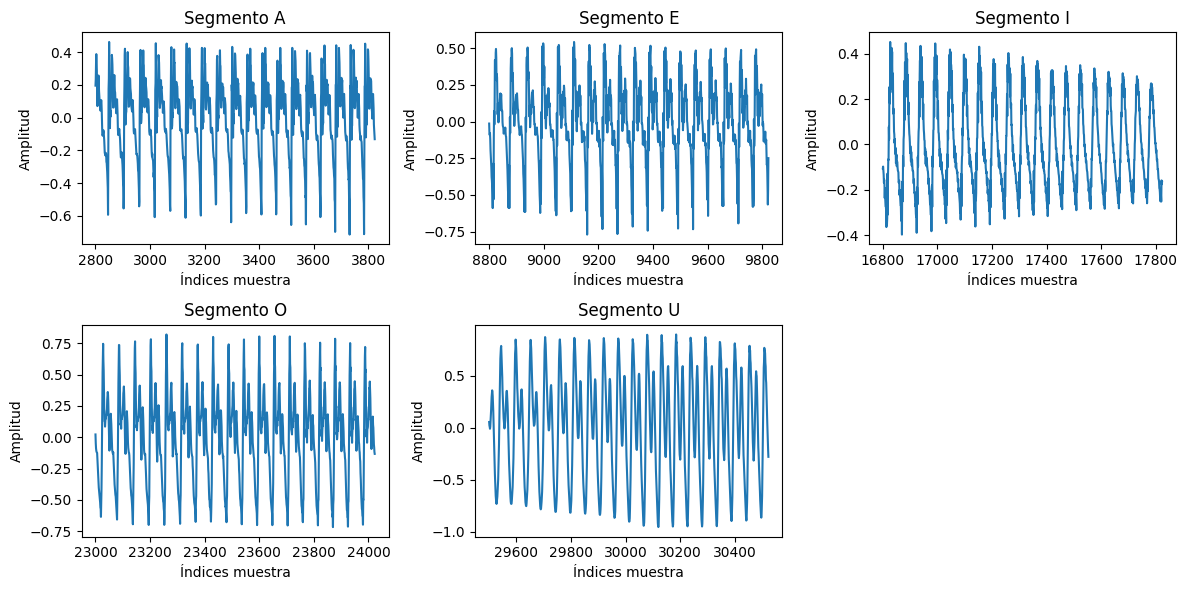

In [144]:
#atras = 1000
#umbrales = [2800-atras, 8500-atras, 16500-atras, 23500-atras, 29750-atras]
#delante = 4700

umbrales = [2800, 8800, 16800, 23000, 29500]
delante = 1024

a = salida[umbrales[0] : umbrales[0]+delante]
e = salida[umbrales[1] : umbrales[1]+delante]
i = salida[umbrales[2] : umbrales[2]+delante]
o = salida[umbrales[3] : umbrales[3]+delante]
u = salida[umbrales[4] : umbrales[4]+delante]
nombres_vocales = ['A', 'E', 'I', 'O', 'U']
vocales = [a,e,i,o,u]

plt.figure(figsize=(12,6))
for i in range(len(vocales)):
    plt.subplot(2,3,i+1)
    plt.title(f"Segmento {nombres_vocales[i]}")
    plt.ylabel("Amplitud")
    plt.xlabel("Índices muestra")
    dom = np.arange(umbrales[i], umbrales[i]+delante, 1)
    plt.plot(dom, vocales[i])
plt.tight_layout()
plt.show()

for i in range(len(vocales)):
    ventana = np.hamming(len(vocales[i]))
    vocales[i] = vocales[i] * ventana
    vocales[i] -= np.mean(vocales[i])
    vocales[i] /= np.max(np.abs(vocales[i]))

In [145]:
def obtener_R(orden, salida):
    R = []
    for p in range(orden+1):
        r_s_i = 0
        for n in range(p, len(salida)):
            r_s_i += salida[n - p] * salida[n]
        R.append(r_s_i/len(salida))
    R = np.array(R)
    return R

def obtener_matriz_coeficientes(orden, R):
    p = orden
    A = np.zeros((p,p))
    E = [R[0]]

    for i in range(0, p):
      elemento = 0
      for j in range(0, i):
          elemento += A[j,i-1] * R[i-j]
      k_i = -1/(E[-1] + 1e-10) * (R[i+1] + elemento)
      A[i,i] = k_i
      for j in range(0, i):
          A[j,i] = A[j,i-1] + k_i*A[i-j-1, i-1]
      E.append(E[-1]*(1 - k_i**2))

    return A, E

from scipy.linalg import solve_toeplitz

def lpc_autocorr(x, p):
    x = x - np.mean(x)
    r = np.correlate(x, x, mode='full')
    r = r[len(x)-1:len(x)+p]
    
    R = (r[:-1], r[:-1])  # Toeplitz
    a = solve_toeplitz(R, -r[1:])
    
    return a



#A = np.zeros((orden,orden))
#E = [R[0]]
orden = 12
Rs = []
As = []
a_s = []
Es = []
for i in range(len(vocales)):
    salida_i = vocales[i]
    R = obtener_R(orden, salida_i)
    A, E = obtener_matriz_coeficientes(orden, R)
    a = lpc_autocorr(salida_i, orden)
    a_s.append(a)
    Rs.append(R)
    As.append(A)
    Es.append(E)
N = len(salida)

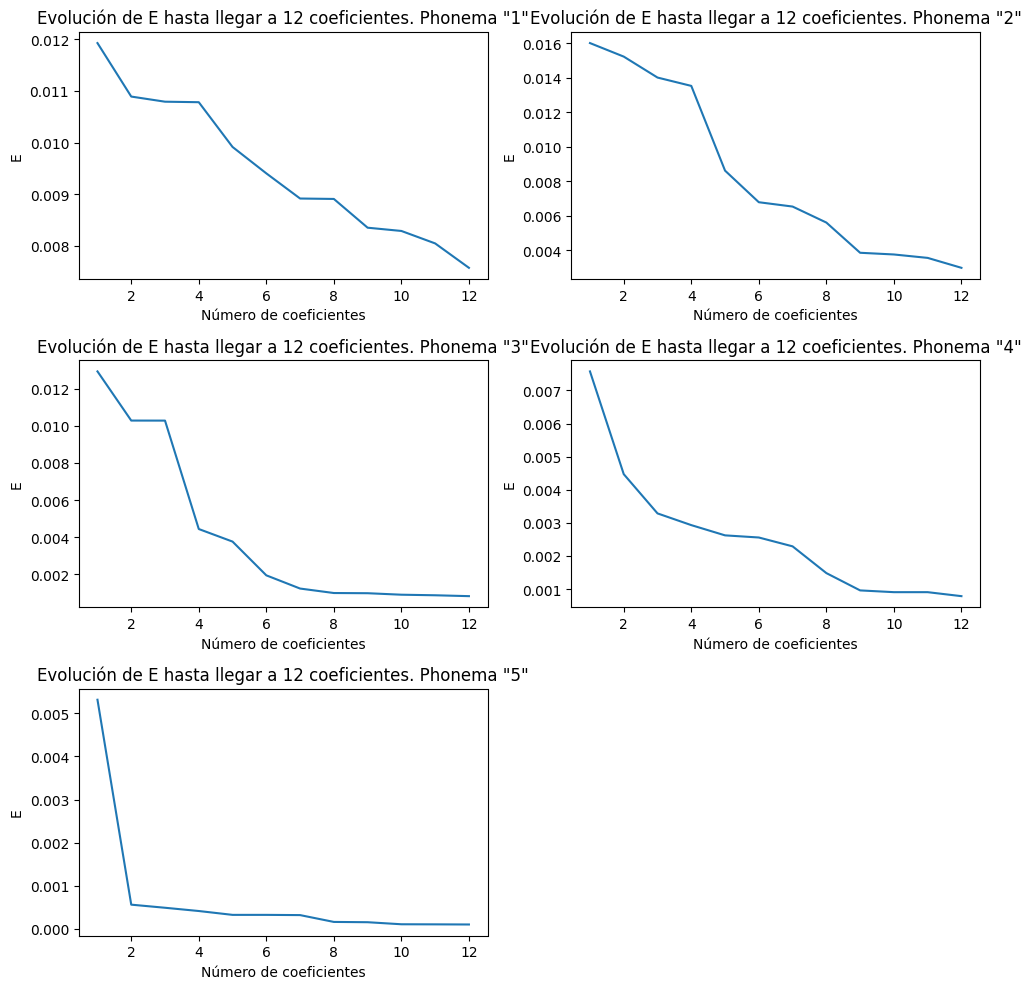

In [146]:
plt.figure(figsize=(10,10))

for i in range(len(Es)):
    plt.subplot(3, 2, i+1)
    dom = np.arange(1,len(Es[i]), 1)
    plt.title(f'Evolución de E hasta llegar a {orden} coeficientes. Phonema "{i+1}"')
    plt.xlabel("Número de coeficientes")
    plt.ylabel("E")
    plt.tight_layout()
    plt.plot(dom, Es[i][1:])
plt.show()

In [147]:
As_definitivos = []
for i in range(len(As)):
    As_definitivos.append(As[i][11])

Es_definitivos = []
for i in range(len(Es)):
    Es_definitivos.append(Es[i][11])

As_definitivos = np.array(As_definitivos)
Es_definitivos = np.array(Es_definitivos)
print(As_definitivos.shape)

Ganancias = np.sqrt(Es_definitivos)

 

(5, 12)


In [148]:
# OBTENIENDO LA RESPUESTA EN FRECUENCIA DEL SISTEMA APROXIMADO

from scipy.signal import freqz

def respuesta_en_frecuencia(a, fs):
    b = [1]
    a_full = np.concatenate(([1], a))

    w, H = freqz(b, a_full, worN=512, fs=fs)
    return w, np.abs(H)

grado_seleccionado = orden - 1

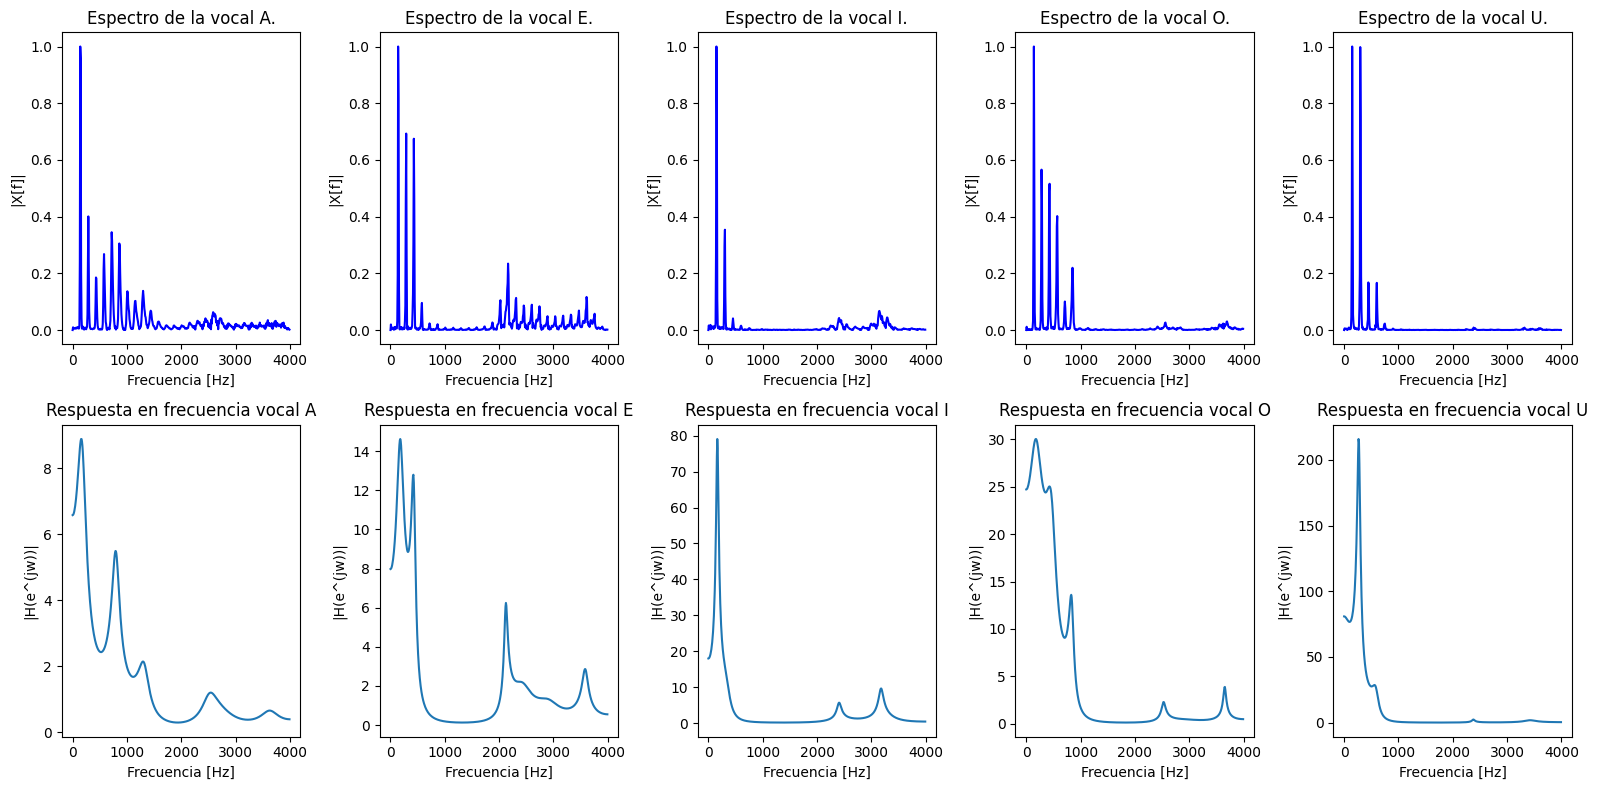

In [149]:
# OBTENIENDO EL ESPECTRO DE LAS SEÑALES
lista_w = []
lista_H = []

plt.figure(figsize=(16,8))
for i in range(len(vocales)):
    N = len(vocales[i])
    w, H_abs = respuesta_en_frecuencia(As[i][:,grado_seleccionado], frecM)
    
    mask_w = w >= 0
    w = w[mask_w]
    H_abs = H_abs[mask_w]
    
    salida = vocales[i]
    S = fft(salida)
    S /= len(S)

    # Frecs
    S_real = np.real(S)
    S_im = np.imag(S)
    S_norm = np.sqrt(S_real**2 + S_im**2)

    frecs = fftfreq(N, d=1/frecM)  # eje de frecuencias

    mask_f = frecs >= 0
    frecs = frecs[mask_f]
    S_norm = np.abs(S[mask_f])

    lista_w.append(w)
    lista_H.append(H_abs)

    # dominio de frecuencias
    plt.subplot(2,5,i+1)
    plt.plot(frecs, np.abs(S_norm)/max(np.abs(S_norm)), label="DFT de la señal", color="blue")
    plt.title(f"Espectro de la vocal {nombres_vocales[i]}.")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|X[f]|")

    plt.subplot(2,5,i+6)
    plt.plot(w, H_abs, label="Modelo AR")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|H(e^(jw))|")
    plt.title(f"Respuesta en frecuencia vocal {nombres_vocales[i]}")

plt.tight_layout()
plt.show()

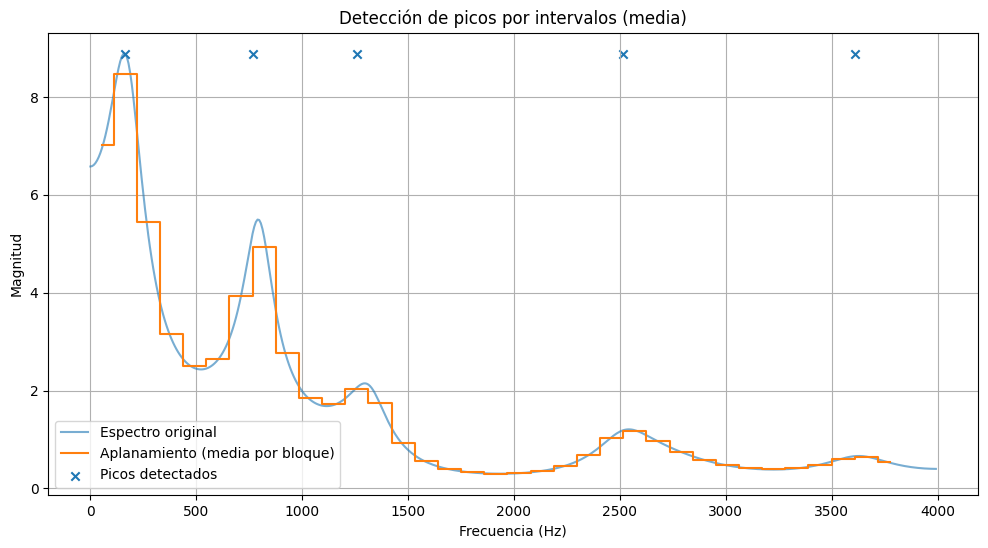

[ 164.0625  765.625  1257.8125 2515.625  3609.375 ]


In [150]:
def obtener_picos(senial, cant_intervalos=100, umbral=0, frecM=8000):    
    
    frecs = fftfreq(delante, d=1/frecM)
    frecs = frecs[: len(frecs)//2]

    N = len(senial)
    tam_intervalo = N // cant_intervalos

    frecuencias = []
    medias = []
    frecs_intervalos = []

    for i in range(cant_intervalos):
        inicio = i * tam_intervalo
        fin = inicio + tam_intervalo
        
        intervalo = senial[inicio:fin]
        
        if len(intervalo) > 0:
            media_val = np.mean(intervalo)
            medias.append(media_val)

            centro = (inicio + fin) // 2 

            if centro < len(frecs):
                freq = frecs[centro]
            else:
                freq = frecs[-1]

            frecuencias.append(freq)
            frecs_intervalos.append(freq)

    medias = np.array(medias)
    frecs_intervalos = np.array(frecs_intervalos)

    diferencias = np.diff(medias)

    i = 0
    frecs_fund = []

    while i < len(diferencias):
        if diferencias[i] > umbral:
            indices_racha = []

            # detectar racha consecutiva
            j = i
            while j < len(diferencias) and diferencias[j] > umbral:
                indices_racha.append(j)
                j += 1

            # tomar los dos últimos de la racha
            if len(indices_racha) >= 2:
                idx1 = indices_racha[-2] + 1
                idx2 = indices_racha[-1] + 1

                freq_media = (frecuencias[idx1] + frecuencias[idx2]) / 2
                frecs_fund.append(freq_media)

            else:
                # si solo hay uno, usar ese normalmente
                idx = indices_racha[0] + 1
                frecs_fund.append(frecuencias[idx])

            i = j
        else:
            i += 1

    frecs_fund = np.array(frecs_fund)

    # ------------------ PLOT ------------------

    plt.figure(figsize=(12,6))

    # señal original
    plt.plot(frecs[:len(senial)], senial, label="Espectro original", alpha=0.6)

    # aplanamiento
    plt.step(frecs_intervalos, medias, where='mid', label="Aplanamiento (media por bloque)")

    # picos detectados
    if len(frecs_fund) > 0:
        y_picos = [np.max(senial)] * len(frecs_fund)
        plt.scatter(frecs_fund, y_picos, marker='x', label="Picos detectados")

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title("Detección de picos por intervalos (media)")
    plt.legend()
    plt.grid()

    plt.show()

    return np.array(diferencias), frecs_fund

FRECS_FUND = []

diferencias, frecs_fund = obtener_picos(lista_H[0], cant_intervalos=35, umbral=2e-4)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)


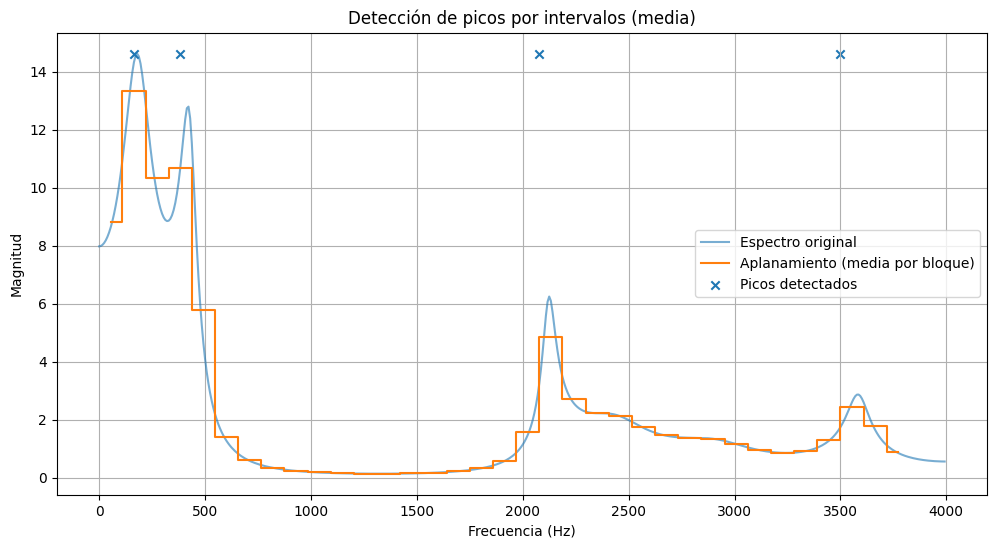

[ 164.0625  382.8125 2078.125  3500.    ]


In [151]:
diferencias, frecs_fund = obtener_picos(lista_H[1], cant_intervalos=35, umbral=2e-4)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

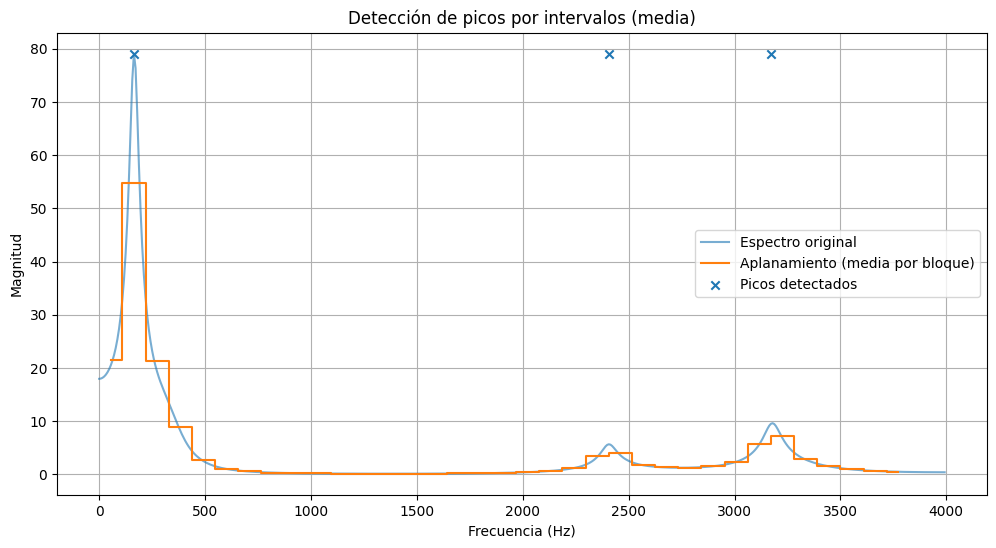

[ 164.0625 2406.25   3171.875 ]


In [152]:
diferencias, frecs_fund = obtener_picos(lista_H[2], cant_intervalos=35, umbral=2e-4)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

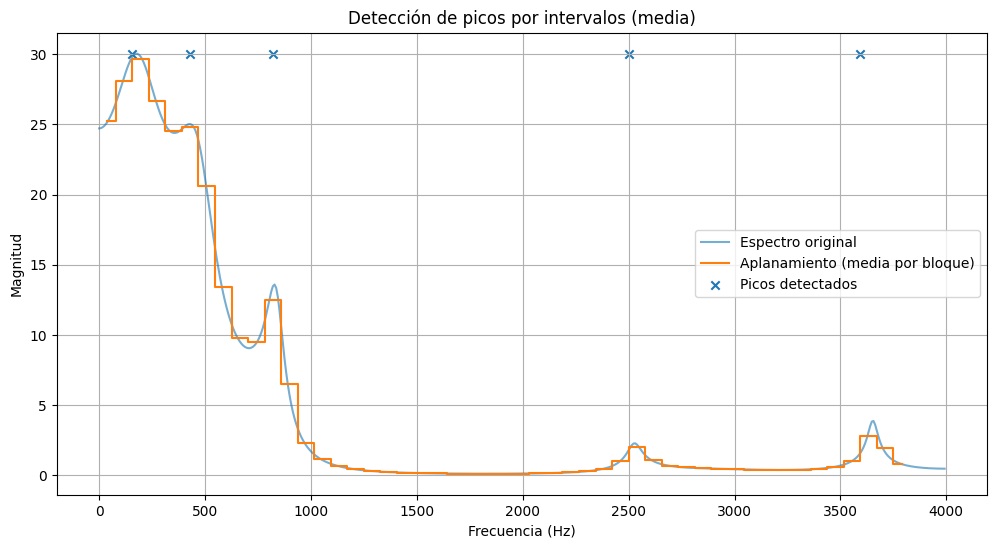

[ 156.25    429.6875  820.3125 2500.     3593.75  ]


In [153]:
diferencias, frecs_fund = obtener_picos(lista_H[3], cant_intervalos=49, umbral=2e-4)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

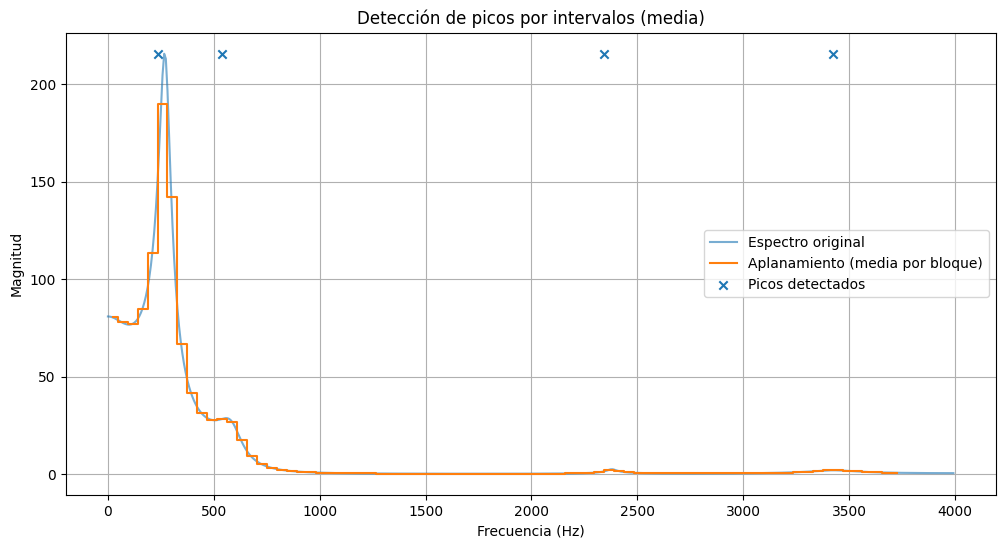

[ 234.375   539.0625 2343.75   3421.875 ]


In [154]:
diferencias, frecs_fund = obtener_picos(lista_H[4], cant_intervalos=80, umbral=2e-4)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

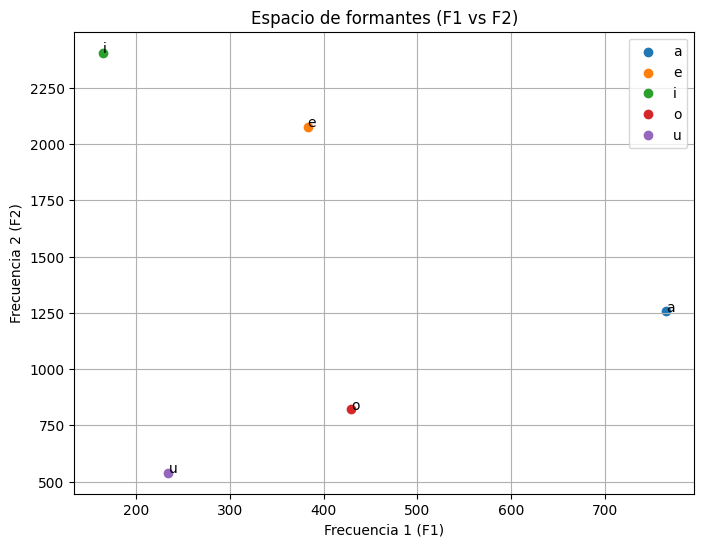

In [156]:
vocales = ['a', 'e', 'i', 'o', 'u']

plt.figure(figsize=(8,6))

for i, frecs in enumerate(FRECS_FUND):
    if len(frecs) >= 2:
        if i in [0,1,3]:
            f1 = frecs[1]
            f2 = frecs[2]
        else:
            f1 = frecs[0] # EN FFT POST-LIFTRADO F1 ES EL PRIMER PICO
            f2 = frecs[1]

        plt.scatter(f1, f2, label=vocales[i])
        plt.text(f1, f2, vocales[i])  # etiqueta en el punto

plt.xlabel("Frecuencia 1 (F1)")
plt.ylabel("Frecuencia 2 (F2)")
plt.title("Espacio de formantes (F1 vs F2)")
plt.grid()
plt.legend()

plt.show()